# Global rotations of unentangled and encoded qubits

This notebook studies the physics behind Fig. 4a of Bluvstein *et al.*, **A fault-tolerant neutral-atom architecture for universal quantum computation**, Nature 649, 39-46 (2026)  (https://www.nature.com/articles/s41586-025-09848-5). It is written as a tutorial for Tsim and small quantum error-correcting codes.

The target question is simple to state and subtle to interpret:

> What happens when the same phase rotation is applied to every physical qubit in an unentangled register, a `[[7,1,3]]` Steane / 2D colour code, and a `[[15,1,3]]` Reed-Muller / 3D colour code?

The answer is that the encoded states have sharp revivals at the angles where the global physical rotation acts as a valid transversal logical gate. The unentangled register revives only at the trivial physical revivals. The 2D colour code revives at Clifford phase angles. The 3D Reed-Muller code has an additional revival at the T angle.

This notebook does **not** use the experimental data, atom images, pulse schedules, lookup-table decoding data, hardware noise, postselection data, or purity rescaling from the paper. It produces an ideal Tsim calculation that reproduces the structure of the Fig. 4a phenomenon.


## Colab setup

The notebook runs in two modes.

- In the Tsim repository documentation build, dependencies are already installed and the first cell does nothing.
- In Google Colab, the first cell installs `bloqade-tsim`, whose import package is `tsim`.

GPU acceleration is not used by Tsim's circuit compiler in this notebook. A separate optional CuPy section is included near the end for dense-vector expectation-value evaluation. For these 7- and 15-qubit examples, CPU execution is usually fast enough.


In [17]:
import subprocess
import sys

try:
    __import__("google.colab")
except Exception:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "bloqade-tsim", "stim"]
    )

In [18]:
import itertools
import time
from dataclasses import dataclass
from functools import cache

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import stim

try:
    from tsim import Circuit
except ImportError:
    from tsim.circuit import Circuit

from tsim.utils.encoder import SteaneEncoder

ANGLE_DEGREES = np.linspace(-180, 180, 145)
SPECIAL_ANGLES = np.array([-180, -135, -90, -45, 0, 45, 90, 135, 180], dtype=float)
RNG_SEED = 119
RUN_TSIM_SPOT_CHECKS = True
RUN_SAMPLING_DEMO = False
USE_CUPY_FOR_DENSE_EXPECTATIONS = False
SAVE_FIGURES = False

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## 1. Rotation convention

A physical phase rotation on one qubit is

$
R_Z(\phi)=\exp\left(-i\frac{\phi}{2}Z\right).
$

Tsim parameterizes the gate as `R_Z(alpha)`, where the physical angle is

$
\phi = \alpha\pi.
$

Thus a plotted angle of `angle_degrees` is passed to Tsim as

$
\alpha = \frac{\texttt{angle\_degrees}}{180}.
$

For a qubit initialized in \(|+\rangle\), the rotation gives

$
\langle X\rangle=\cos(\phi),\qquad
\langle Y\rangle=\sin(\phi).
$

This sign matters. The T gate in the paper is $T=\exp(-i\pi Z/8)$, which is a 45-degree rotation around $Z$. In Tsim syntax that is `R_Z(0.25)`.


In [19]:
SINGLE_QUBIT_PAULIS = {
    "X": np.array([[0, 1], [1, 0]], dtype=complex),
    "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),
    "Z": np.array([[1, 0], [0, -1]], dtype=complex),
}

rows = []
for alpha in [0.0, 0.25, 0.5, 1.0, -0.25]:
    state = np.asarray(Circuit(f"RX 0\nR_Z({alpha}) 0").to_matrix()).reshape(-1)
    x_value = float(np.real(np.vdot(state, SINGLE_QUBIT_PAULIS["X"] @ state)))
    y_value = float(np.real(np.vdot(state, SINGLE_QUBIT_PAULIS["Y"] @ state)))
    expected_x = float(np.cos(np.pi * alpha))
    expected_y = float(np.sin(np.pi * alpha))
    assert np.allclose([x_value, y_value], [expected_x, expected_y], atol=1e-12)
    rows.append((alpha, x_value, y_value, expected_x, expected_y))

lines = [
    "| alpha | Tsim <X> | Tsim <Y> | analytic <X> | analytic <Y> |",
    "|---:|---:|---:|---:|---:|",
]
for alpha, x_value, y_value, expected_x, expected_y in rows:
    lines.append(
        f"| {alpha: .2f} | {x_value: .10f} | {y_value: .10f} | "
        f"{expected_x: .10f} | {expected_y: .10f} |"
    )
display(Markdown("\n".join(lines)))

| alpha | Tsim <X> | Tsim <Y> | analytic <X> | analytic <Y> |
|---:|---:|---:|---:|---:|
|  0.00 |  1.0000000000 |  0.0000000000 |  1.0000000000 |  0.0000000000 |
|  0.25 |  0.7071067812 |  0.7071067812 |  0.7071067812 |  0.7071067812 |
|  0.50 |  0.0000000000 |  1.0000000000 |  0.0000000000 |  1.0000000000 |
|  1.00 | -1.0000000000 |  0.0000000000 | -1.0000000000 |  0.0000000000 |
| -0.25 |  0.7071067812 | -0.7071067812 |  0.7071067812 | -0.7071067812 |

## 2. What is being measured?

Let

$
U_Z(\phi)=\prod_{q=0}^{n-1}\exp\left(-i\frac{\phi}{2}Z_q\right)
$

be the global physical rotation. We prepare a state $|\psi_0\rangle$, rotate it to $|\psi(\phi)\rangle=U_Z(\phi)|\psi_0\rangle$, and evaluate quantities that separate three ideas that are blended together in the paper figure: raw logical observables, decoded logical observables, and stabilizer revival.

### Decoded logical X projection

The upper panel follows the measurement logic of Fig. 4a more closely than a bare Pauli expectation. We compute the exact X-basis probability distribution of the rotated state, infer the X-type stabilizer syndrome, apply a deterministic minimum-weight Z-error lookup-table decoder, and average the decoded logical X outcome. For a measurement bit string $m\in\{0,1\}^n$, the decoder uses

$
s(m)=H_Xm,\qquad \ell_{\rm dec}(m)=\ell_X\cdot(m+c(s))\pmod 2,
$

where $H_X$ contains the X-check supports, $\ell_X$ is the logical-X support, and $c(s)$ is the chosen minimum-weight correction for syndrome $s$. The decoded logical signal is

$
L_X^{\rm dec}(\phi)=
\frac{\sum_{m\in A(\phi)}p_\phi(m)(-1)^{\ell_{\rm dec}(m)}}
     {\sum_{m\in A(\phi)}p_\phi(m)}.
$

The accepted set $A(\phi)$ is formed by ordering outcomes by decoder correction weight. If the acceptance cut crosses a weight class, that whole weight class is included proportionally, avoiding an arbitrary tie break. The defaults use the acceptance fractions stated in the paper's Methods: 46% for the 15-qubit 3D-code-style curves and 74% for the 7-qubit 2D code. In this noiseless tutorial, this is not modelling loss or hardware noise; it is the ideal decoded/postselected observable.

This distinction is important. The bare expectation $\langle X_L\rangle$ has the right values exactly at the special angles, but it can wash out the flat regions between them. The decoded observable shows the plateau structure expected from stabilizer-assisted correction of nearby coherent rotations.

### Raw logical observables

For diagnostics we also compute

$
L_X(\phi)=\langle\psi(\phi)|X_L|\psi(\phi)\rangle,
\qquad
L_Y(\phi)=\langle\psi(\phi)|Y_L|\psi(\phi)\rangle.
$

These are useful for checking the ideal logical gate at the exact robust angles. For example, an ideal logical T applied to $|+_L\rangle$ gives $L_X=L_Y=1/\sqrt2$, up to the chosen sign convention.

### X-stabilizer response

For CSS codes in $|+_L\rangle$, the global $Z$ rotation primarily disturbs the X checks. We plot

$
A_X(\phi)=\frac{1}{r_X}\sum_{j=1}^{r_X}\left|\langle S_j^X\rangle_\phi\right|,
$

where $r_X$ is the number of independent X stabilizers. The absolute value matches the stabilizer-revival role of the lower panel: a stabilizer with sign $-1$ is still a sharp stabilizer, but it is in the wrong syndrome sector.

### Positive-syndrome projector

For diagnostics we also evaluate

$
P_X(\phi)=\left\langle\prod_{j=1}^{r_X}\frac{I+S_j^X}{2}\right\rangle_\phi.
$

This is the probability that ideal X-check measurements return all positive signs. It is a noiseless code-space diagnostic, not the paper's experimental acceptance fraction.

All final comparison curves are normalized by their own maximum absolute value. This keeps the tutorial calculation independent of the paper's hardware normalization pipeline while retaining the unity-maximum plotting convention.


## 3. Pauli and state-vector utilities

The default calculation uses exact state vectors. Tsim prepares the initial states and verifies selected full circuits. For the full angle grid, the global Z rotation is applied as a diagonal phase to the state vector. This avoids recompiling the same non-Clifford circuit at every angle and makes the `[[15,1,3]]` curve safe to run by default.

Tsim and Stim use qubit 0 as the most significant axis in the state-vector indexing used below. The one-qubit convention check above fixes the sign and ordering.


In [20]:
PAULI_MUL = {
    ("I", "I"): (1, "I"),
    ("I", "X"): (1, "X"),
    ("I", "Y"): (1, "Y"),
    ("I", "Z"): (1, "Z"),
    ("X", "I"): (1, "X"),
    ("X", "X"): (1, "I"),
    ("X", "Y"): (1j, "Z"),
    ("X", "Z"): (-1j, "Y"),
    ("Y", "I"): (1, "Y"),
    ("Y", "X"): (-1j, "Z"),
    ("Y", "Y"): (1, "I"),
    ("Y", "Z"): (1j, "X"),
    ("Z", "I"): (1, "Z"),
    ("Z", "X"): (1j, "Y"),
    ("Z", "Y"): (-1j, "X"),
    ("Z", "Z"): (1, "I"),
}


@dataclass(frozen=True)
class Observable:
    coefficient: complex
    pauli: str


def multiply_paulis(left: str, right: str) -> tuple[complex, str]:
    phase = 1
    out = []
    for a, b in zip(left, right, strict=True):
        local_phase, local_pauli = PAULI_MUL[(a, b)]
        phase *= local_phase
        out.append(local_pauli)
    return phase, "".join(out)


def generated_group(generators: list[str]) -> list[tuple[complex, str]]:
    identity = "I" * len(generators[0])
    group = []
    for bits in itertools.product([0, 1], repeat=len(generators)):
        phase = 1
        pauli = identity
        for bit, generator in zip(bits, generators, strict=True):
            if bit:
                local_phase, pauli = multiply_paulis(pauli, generator)
                phase *= local_phase
        group.append((phase, pauli))
    return group


@cache
def pauli_action(pauli: str) -> tuple[np.ndarray, np.ndarray]:
    n = len(pauli)
    indices = np.arange(1 << n, dtype=np.uint64)
    flip_mask = 0
    z_mask = 0
    y_count = 0
    for qubit, axis in enumerate(pauli):
        bit_position = n - 1 - qubit
        if axis in "XY":
            flip_mask |= 1 << bit_position
        if axis in "YZ":
            z_mask |= 1 << bit_position
        if axis == "Y":
            y_count += 1
    parity = np.array(
        [((int(index) & z_mask).bit_count() & 1) for index in indices],
        dtype=np.int8,
    )
    phase = ((1j) ** y_count) * (1 - 2 * parity)
    return indices ^ np.uint64(flip_mask), phase


@cache
def hamming_weights(n: int) -> np.ndarray:
    return np.array([index.bit_count() for index in range(1 << n)], dtype=np.int16)


def pauli_expectation_complex(state: np.ndarray, pauli: str) -> complex:
    partner, phase = pauli_action(pauli)
    return np.sum(np.conjugate(state[partner]) * phase * state)


def pauli_expectation(state: np.ndarray, pauli: str) -> float:
    return float(np.real_if_close(pauli_expectation_complex(state, pauli)).real)


def observable_expectation(state: np.ndarray, observable: Observable) -> float:
    value = observable.coefficient * pauli_expectation_complex(state, observable.pauli)
    return float(np.real_if_close(value).real)


def apply_pauli_to_state(state: np.ndarray, pauli: str) -> np.ndarray:
    partner, phase = pauli_action(pauli)
    out = np.empty_like(state)
    out[partner] = phase * state
    return out


def pauli_string(n: int, axis: str, support: list[int] | np.ndarray) -> str:
    text = ["I"] * n
    for qubit in support:
        text[int(qubit)] = axis
    return "".join(text)


def stim_pauli_text(pauli: str) -> str:
    return pauli.replace("I", "_")


def logical_y_from_xz(logical_x: str, logical_z: str) -> Observable:
    phase, pauli = multiply_paulis(logical_x, logical_z)
    coefficient = 1j * phase
    assert np.isclose(coefficient.imag, 0.0, atol=1e-12)
    return Observable(float(np.real(coefficient)), pauli)


def orient_y_to_positive_rotation(
    base_state: np.ndarray,
    n: int,
    logical_y: Observable,
    probe_angle_degrees: float = 1.0,
) -> Observable:
    test_state = rotate_state_from_base(base_state, n, probe_angle_degrees)
    if observable_expectation(test_state, logical_y) < 0:
        return Observable(-logical_y.coefficient, logical_y.pauli)
    return logical_y


def normalized_state(circuit: Circuit) -> np.ndarray:
    state = np.asarray(circuit.to_matrix()).reshape(-1)
    return state / np.sqrt(np.vdot(state, state).real)


def rotate_state_from_base(
    base_state: np.ndarray,
    n: int,
    angle_degrees: float,
) -> np.ndarray:
    theta = np.deg2rad(angle_degrees)
    phases = np.exp(-0.5j * theta * (n - 2 * hamming_weights(n)))
    return base_state * phases


def append_global_rz(circuit: Circuit, angle_degrees: float) -> Circuit:
    rotated = circuit.copy()
    for qubit in range(circuit.num_qubits):
        rotated.append("R_Z", [qubit], arg=angle_degrees / 180)
    return rotated


def state_from_tsim_with_global_rz(
    circuit: Circuit, angle_degrees: float
) -> np.ndarray:
    return normalized_state(append_global_rz(circuit, angle_degrees))


def x_projected_expectation(
    state: np.ndarray,
    x_stabilizers: list[str],
    observable: Observable,
) -> float:
    value = 0j
    for phase, stabilizer in generated_group(x_stabilizers):
        local_phase, pauli = multiply_paulis(stabilizer, observable.pauli)
        value += (
            phase
            * local_phase
            * observable.coefficient
            * pauli_expectation_complex(
                state,
                pauli,
            )
        )
    return float(np.real_if_close(value / (2 ** len(x_stabilizers))).real)


def x_projector_probability(state: np.ndarray, x_stabilizers: list[str]) -> float:
    value = 0j
    for phase, pauli in generated_group(x_stabilizers):
        value += phase * pauli_expectation_complex(state, pauli)
    return float(np.real_if_close(value / (2 ** len(x_stabilizers))).real)


def mean_abs_expectation(state: np.ndarray, observables: list[str]) -> float:
    return float(
        np.mean(
            [abs(pauli_expectation(state, observable)) for observable in observables]
        )
    )


def mean_signed_expectation(state: np.ndarray, observables: list[str]) -> float:
    return float(
        np.mean([pauli_expectation(state, observable) for observable in observables])
    )


def normalize_signed(values: np.ndarray) -> np.ndarray:
    scale = np.max(np.abs(values))
    if scale == 0:
        raise ValueError("Cannot normalize a zero curve.")
    return values / scale


def normalize_positive(values: np.ndarray) -> np.ndarray:
    scale = np.max(values)
    if scale == 0:
        raise ValueError("Cannot normalize a zero curve.")
    return values / scale


@cache
def computational_basis_bits(n: int) -> np.ndarray:
    indices = np.arange(1 << n, dtype=np.uint32)
    return np.array(
        [((indices >> (n - 1 - qubit)) & 1) for qubit in range(n)],
        dtype=np.uint8,
    ).T


def x_support_row(pauli: str) -> np.ndarray:
    return np.array([axis == "X" for axis in pauli], dtype=np.uint8)


@cache
def x_basis_hadamard_matrix_size(n: int) -> int:
    return 1 << n


def x_basis_amplitudes(state: np.ndarray) -> np.ndarray:
    out = state.copy()
    size = out.shape[0]
    half_width = 1
    inv_sqrt2 = 1 / np.sqrt(2)
    while half_width < size:
        out = out.reshape(-1, 2 * half_width)
        left = out[:, :half_width].copy()
        right = out[:, half_width : 2 * half_width].copy()
        out[:, :half_width] = (left + right) * inv_sqrt2
        out[:, half_width : 2 * half_width] = (left - right) * inv_sqrt2
        out = out.reshape(size)
        half_width *= 2
    return out


@dataclass(frozen=True)
class XBasisDecoder:
    decoded_sign: np.ndarray
    correction_weight: np.ndarray


def syndrome_id(bits: np.ndarray) -> int:
    out = 0
    for bit in bits:
        out = (out << 1) | int(bit)
    return out


def make_x_basis_decoder(
    x_stabilizers: list[str], logical_x: Observable
) -> XBasisDecoder:
    n = len(logical_x.pauli)
    checks = np.array([x_support_row(pauli) for pauli in x_stabilizers], dtype=np.uint8)
    logical = x_support_row(logical_x.pauli)
    correction_weight_by_syndrome = np.full(1 << len(x_stabilizers), n + 1, dtype=int)
    correction_logical_by_syndrome = np.zeros(1 << len(x_stabilizers), dtype=np.uint8)

    for index in range(1 << n):
        error = computational_basis_bits(n)[index]
        syndrome = syndrome_id((checks @ error) % 2)
        weight = int(np.sum(error))
        logical_flip = int(np.dot(logical, error) % 2)
        if weight < correction_weight_by_syndrome[syndrome]:
            correction_weight_by_syndrome[syndrome] = weight
            correction_logical_by_syndrome[syndrome] = logical_flip

    measurement_bits = computational_basis_bits(n)
    syndrome_bits = (measurement_bits @ checks.T) % 2
    syndrome_ids = np.array(
        [syndrome_id(row) for row in syndrome_bits], dtype=np.uint16
    )
    raw_logical = (measurement_bits @ logical) % 2
    decoded_logical = raw_logical ^ correction_logical_by_syndrome[syndrome_ids]
    decoded_sign = 1 - 2 * decoded_logical.astype(np.int8)
    correction_weight = correction_weight_by_syndrome[syndrome_ids]
    return XBasisDecoder(
        decoded_sign=decoded_sign.astype(float), correction_weight=correction_weight
    )


def decoded_logical_x_expectation(
    state: np.ndarray,
    decoder: XBasisDecoder,
    acceptance_fraction: float,
) -> tuple[float, float]:
    probabilities = np.abs(x_basis_amplitudes(state)) ** 2
    max_weight = int(np.max(decoder.correction_weight))
    probability_by_weight = np.bincount(
        decoder.correction_weight,
        weights=probabilities,
        minlength=max_weight + 1,
    )
    numerator_by_weight = np.bincount(
        decoder.correction_weight,
        weights=probabilities * decoder.decoded_sign,
        minlength=max_weight + 1,
    )
    target = acceptance_fraction * float(np.sum(probabilities))
    accepted = 0.0
    numerator = 0.0
    for probability, local_numerator in zip(
        probability_by_weight, numerator_by_weight, strict=True
    ):
        if probability <= 1e-15:
            continue
        if accepted + probability <= target + 1e-15:
            accepted += probability
            numerator += local_numerator
        else:
            fraction = max(target - accepted, 0.0) / probability
            accepted += fraction * probability
            numerator += fraction * local_numerator
            break
    if accepted <= 0:
        raise ValueError("No shots accepted by the decoder.")
    return float(numerator / accepted), float(accepted)

## 4. Why stabilizer codes suppress small global rotations

The suppression can be seen directly by expanding the physical rotation. For small $\phi$,

$
R_Z(\phi)=\cos(\phi/2)I-i\sin(\phi/2)Z.
$

A global rotation on $n$ qubits therefore creates a coherent superposition of all possible products of $Z$ errors:

$
U_Z(\phi)=\sum_{E\subseteq\{0,\dots,n-1\}} c_E(\phi)Z_E,
$

where the coefficient for a weight $w$ error scales as $\sin^w(\phi/2)\cos^{n-w}(\phi/2)$. A distance $d$ code has no nontrivial logical Pauli operator of weight below $d$. Low-weight terms therefore move $|+_L\rangle$ into detectable syndrome sectors instead of immediately producing a logical rotation. The leading coherent logical term appears only at weight at least $d$.

That is the local, small-angle statement. Fig. 4a is a global-angle statement. At special angles the full tensor product rotation is no longer a small error: it is exactly a transversal logical gate of the code. At those angles the stabilizers revive and the logical response lies on a plateau.


## 5. The `[[7,1,3]]` Steane / 2D colour code

The Steane code is a CSS code with three X checks, three Z checks, one logical qubit, and distance 3. It is also the smallest triangular 2D colour code. In the Tsim `SteaneEncoder` ordering used here the X and Z stabilizers have the same supports,

$
0123,\qquad 1245,\qquad 2346,
$

with a representative logical support \(015\).

The Steane code has transversal Clifford phase rotations. A global 90-degree phase rotation acts as a logical $S$ -type operation up to Pauli-frame conventions. The code therefore has stabilizer revivals at multiples of 90 degrees. Its logical X projection is 1 at the identity, 0 at the logical $S$ angle, and -1 at the logical $Z$ angle.

The cells below verify the encoder in two independent ways:

1. Stim flow checks verify that the encoder maps an input physical qubit's $X$ and $Z$ operators to the chosen encoded $X_L$ and $Z_L$.
2. Tsim state-vector checks verify that the prepared $|+_L\rangle$ is stabilized by all Steane stabilizers and by $X_L$.


In [21]:
steane_encoder = SteaneEncoder()
steane_n = steane_encoder.n
steane_x_stabilizers = [
    pauli_string(steane_n, "X", support)
    for support in steane_encoder.stabilizer_generators
]
steane_z_stabilizers = [
    pauli_string(steane_n, "Z", support)
    for support in steane_encoder.stabilizer_generators
]
steane_logical_x = Observable(
    1, pauli_string(steane_n, "X", steane_encoder.observables[0])
)
steane_logical_z = pauli_string(steane_n, "Z", steane_encoder.observables[0])
steane_logical_y = logical_y_from_xz(steane_logical_x.pauli, steane_logical_z)

input_x = pauli_string(steane_n, "X", [steane_encoder.encoding_qubit])
input_z = pauli_string(steane_n, "Z", [steane_encoder.encoding_qubit])
encoding_circuit = stim.Circuit(steane_encoder.encoding_program_text)
encoding_flows = [
    stim.Flow(
        f"{stim_pauli_text(input_x)} -> {stim_pauli_text(steane_logical_x.pauli)}"
    ),
    stim.Flow(f"{stim_pauli_text(input_z)} -> {stim_pauli_text(steane_logical_z)}"),
]
assert encoding_circuit.has_all_flows(encoding_flows)

steane_prep_circuit = stim.Circuit(
    f"RX {steane_encoder.encoding_qubit}\n" + steane_encoder.encoding_program_text
)
prepared_flows = [
    stim.Flow(f"1 -> {stim_pauli_text(pauli)}")
    for pauli in steane_x_stabilizers + steane_z_stabilizers + [steane_logical_x.pauli]
]
assert steane_prep_circuit.has_all_flows(prepared_flows)

steane_builder = SteaneEncoder()
steane_builder.initialize("RX 0")
steane_base_circuit = steane_builder.circuit
steane_base_state = normalized_state(steane_base_circuit)
steane_logical_y = orient_y_to_positive_rotation(
    steane_base_state, steane_n, steane_logical_y
)

for pauli in steane_x_stabilizers + steane_z_stabilizers:
    assert np.isclose(pauli_expectation(steane_base_state, pauli), 1.0, atol=1e-12)
assert np.isclose(
    observable_expectation(steane_base_state, steane_logical_x), 1.0, atol=1e-12
)

print("Steane verification passed")
print(f"encoder flow generators: {len(encoding_circuit.flow_generators())}")
print(f"prepared-state flow generators: {len(steane_prep_circuit.flow_generators())}")
print("X stabilizers:", ", ".join(steane_x_stabilizers))
print("logical X:", steane_logical_x.pauli)
print("logical Z:", steane_logical_z)
print(
    f"logical Y: coefficient {steane_logical_y.coefficient:+.0f}, Pauli {steane_logical_y.pauli}"
)

Steane verification passed
encoder flow generators: 8
prepared-state flow generators: 7
X stabilizers: XXXXIII, IXXIXXI, IIXXXIX
logical X: XXIIIXI
logical Z: ZZIIIZI
logical Y: coefficient +1, Pauli YYIIIYI


## 6. The `[[15,1,3]]` Reed-Muller / 3D colour code

The 15-qubit quantum Reed-Muller code is the smallest 3D colour-code member used for transversal T gates. A convenient algebraic construction labels qubits by the 15 nonzero columns of a four-bit vector space:

$
q\in \mathbb F_2^4\setminus\{0000\}.
$

The X checks are the four coordinate rows. Each has weight 8. The logical X operator is

$
X_L=X^{\otimes 15}.
$

The Z checks are all binary vectors orthogonal to the four coordinate rows and to the all-ones logical-X row. This gives rank 10. Together with the four X checks, there are 14 independent stabilizers, so

$
k=n-r_X-r_Z=15-4-10=1.
$

The crucial extra property is triorthogonality. It makes \(T^{\otimes 15}\), with $T=R_Z(45^\circ)$, act as a logical T-type operation on the encoded qubit. That is why the 3D curve has a 45-degree stabilizer revival and a logical-X plateau near $1/\sqrt2$.

The state used below is synthesized from the verified stabilizer generators using Stim, then converted to a Tsim circuit. This is an equivalent stabilizer-state preparation for the ideal tutorial calculation; it is not the neutral-atom hypercube encoder from the experiment.


In [22]:
def gf2_rank(rows: list[np.ndarray] | np.ndarray) -> int:
    rows_array = np.asarray(rows, dtype=np.uint8)
    if rows_array.ndim == 1:
        rows_array = rows_array.reshape(1, -1)
    n = rows_array.shape[1]
    rows_int = [
        int(sum(int(bit) << i for i, bit in enumerate(row)))
        for row in rows_array
        if np.any(row)
    ]
    rank = 0
    for column in range(n):
        pivot = next(
            (i for i in range(rank, len(rows_int)) if (rows_int[i] >> column) & 1),
            None,
        )
        if pivot is None:
            continue
        rows_int[rank], rows_int[pivot] = rows_int[pivot], rows_int[rank]
        for i in range(len(rows_int)):
            if i != rank and ((rows_int[i] >> column) & 1):
                rows_int[i] ^= rows_int[rank]
        rank += 1
    return rank


def gf2_nullspace_basis(matrix: np.ndarray) -> list[np.ndarray]:
    matrix = np.asarray(matrix, dtype=np.uint8)
    n = matrix.shape[1]
    rows = [int(sum(int(bit) << i for i, bit in enumerate(row))) for row in matrix]
    pivots = []
    row_index = 0
    for column in range(n):
        pivot = next(
            (i for i in range(row_index, len(rows)) if (rows[i] >> column) & 1),
            None,
        )
        if pivot is None:
            continue
        rows[row_index], rows[pivot] = rows[pivot], rows[row_index]
        for i in range(len(rows)):
            if i != row_index and ((rows[i] >> column) & 1):
                rows[i] ^= rows[row_index]
        pivots.append(column)
        row_index += 1

    free_columns = [column for column in range(n) if column not in pivots]
    basis = []
    for free_column in free_columns:
        vector = 1 << free_column
        for row_number, pivot_column in enumerate(pivots):
            if (rows[row_number] >> free_column) & 1:
                vector |= 1 << pivot_column
        basis.append(np.array([(vector >> i) & 1 for i in range(n)], dtype=np.uint8))
    return basis


rm_n = 15
rm_columns = np.array(
    [[int(bit) for bit in f"{value:04b}"] for value in range(1, 16)],
    dtype=np.uint8,
).T
rm_logical_x_row = np.ones(rm_n, dtype=np.uint8)
rm_x_rows = [row.copy() for row in rm_columns]
rm_z_rows = gf2_nullspace_basis(np.vstack([rm_logical_x_row, *rm_x_rows]))

rm_logical_z_row = None
for support in itertools.combinations(range(rm_n), 3):
    candidate = np.zeros(rm_n, dtype=np.uint8)
    candidate[list(support)] = 1
    if (
        all(np.dot(candidate, row) % 2 == 0 for row in rm_x_rows)
        and np.dot(candidate, rm_logical_x_row) % 2 == 1
    ):
        rm_logical_z_row = candidate
        break

assert rm_logical_z_row is not None
assert gf2_rank(rm_x_rows) == 4
assert gf2_rank(rm_z_rows) == 10
assert len(rm_x_rows) + len(rm_z_rows) == 14
assert np.dot(rm_logical_x_row, rm_logical_z_row) % 2 == 1

for x_row in rm_x_rows:
    for z_row in rm_z_rows:
        assert np.dot(x_row, z_row) % 2 == 0

rm_x_stabilizers = [pauli_string(rm_n, "X", np.flatnonzero(row)) for row in rm_x_rows]
rm_z_stabilizers = [pauli_string(rm_n, "Z", np.flatnonzero(row)) for row in rm_z_rows]
rm_logical_x = Observable(1, pauli_string(rm_n, "X", np.flatnonzero(rm_logical_x_row)))
rm_logical_z = pauli_string(rm_n, "Z", np.flatnonzero(rm_logical_z_row))
rm_logical_y = logical_y_from_xz(rm_logical_x.pauli, rm_logical_z)

rm_stim_stabilizers = [
    stim.PauliString("+" + stim_pauli_text(pauli))
    for pauli in rm_x_stabilizers + rm_z_stabilizers + [rm_logical_x.pauli]
]
rm_stim_prep = stim.Tableau.from_stabilizers(
    rm_stim_stabilizers,
    allow_underconstrained=False,
    allow_redundant=False,
).to_circuit(method="graph_state")
rm_expected_flows = [
    stim.Flow(f"1 -> {stim_pauli_text(pauli)}")
    for pauli in rm_x_stabilizers + rm_z_stabilizers + [rm_logical_x.pauli]
]
assert rm_stim_prep.has_all_flows(rm_expected_flows)

rm_base_circuit = Circuit.from_stim_program(rm_stim_prep)
rm_base_state = normalized_state(rm_base_circuit)
rm_logical_y = orient_y_to_positive_rotation(rm_base_state, rm_n, rm_logical_y)

for pauli in rm_x_stabilizers + rm_z_stabilizers:
    assert np.isclose(pauli_expectation(rm_base_state, pauli), 1.0, atol=1e-12)
assert np.isclose(observable_expectation(rm_base_state, rm_logical_x), 1.0, atol=1e-12)

rm_t_state = rotate_state_from_base(rm_base_state, rm_n, 45.0)
assert np.isclose(mean_abs_expectation(rm_t_state, rm_x_stabilizers), 1.0, atol=1e-12)
assert np.isclose(
    observable_expectation(rm_t_state, rm_logical_x), 1 / np.sqrt(2), atol=1e-12
)
assert np.isclose(
    abs(observable_expectation(rm_t_state, rm_logical_y)), 1 / np.sqrt(2), atol=1e-12
)

print("Reed-Muller verification passed")
print(f"rank(X checks): {gf2_rank(rm_x_rows)}")
print(f"rank(Z checks): {gf2_rank(rm_z_rows)}")
print(f"logical Z support: {[int(q) for q in np.flatnonzero(rm_logical_z_row)]}")
print(f"prepared-state flow generators: {len(rm_stim_prep.flow_generators())}")
print(
    f"logical Y: coefficient {rm_logical_y.coefficient:+.0f}, Pauli {rm_logical_y.pauli}"
)

Reed-Muller verification passed
rank(X checks): 4
rank(Z checks): 10
logical Z support: [0, 1, 2]
prepared-state flow generators: 15
logical Y: coefficient +1, Pauli YYYXXXXXXXXXXXX


## 7. Unentangled and negative-stabilizer controls

### Unentangled baseline

The unentangled baseline starts in

$
|+\rangle^{\otimes 15}.
$

It is then analysed with the same Reed-Muller logical-X and X-check observables. Because no stabilizer-code entanglement is present, the response factorizes. In particular,

$
\langle X^{\otimes 15}\rangle = \cos^{15}\phi.
$

The baseline therefore revives at 180-degree physical revivals, not at 90-degree Clifford code revivals or 45-degree T-code revivals.

### Negative-stabilizer Reed-Muller control

The Nature figure also compares a 3D code with incorrect stabilizer signs. In this notebook, we build a transparent control by applying physical X flips to the four basis-vector qubits of the Reed-Muller coordinate labelling. This keeps $X_L=+1$ at zero angle but flips several Z-stabilizer signs. It removes the 45-degree T plateau while preserving Clifford-like revivals.




In [23]:
product_base_circuit = Circuit("RX " + " ".join(str(q) for q in range(rm_n)))
product_base_state = normalized_state(product_base_circuit)

rm_corner_qubits = [0, 1, 3, 7]
rm_corner_flip = pauli_string(rm_n, "X", rm_corner_qubits)
rm_negative_base_state = apply_pauli_to_state(rm_base_state, rm_corner_flip)

assert np.allclose(
    abs(np.vdot(product_base_state, np.ones(1 << rm_n) / np.sqrt(1 << rm_n))), 1.0
)
for pauli in rm_x_stabilizers:
    assert np.isclose(pauli_expectation(rm_negative_base_state, pauli), 1.0, atol=1e-12)
assert np.isclose(
    observable_expectation(rm_negative_base_state, rm_logical_x), 1.0, atol=1e-12
)
negative_z_signs = np.array(
    [pauli_expectation(rm_negative_base_state, pauli) for pauli in rm_z_stabilizers]
)
assert np.any(negative_z_signs < 0)

negative_t_state = rotate_state_from_base(rm_negative_base_state, rm_n, 45.0)
assert mean_abs_expectation(negative_t_state, rm_x_stabilizers) < 1e-9

print("Unentangled baseline and negative-stabilizer control verified")
print(
    f"negative-stabilizer control uses physical X flips on qubits: {rm_corner_qubits}"
)
print(f"number of flipped Z-check signs: {int(np.sum(negative_z_signs < 0))}")

Unentangled baseline and negative-stabilizer control verified
negative-stabilizer control uses physical X flips on qubits: [0, 1, 3, 7]
number of flipped Z-check signs: 4


## 8. Full-rotation Tsim spot checks

The full curves below rotate the base state by multiplying computational-basis amplitudes by the exact diagonal phase. To confirm that this matches Tsim's circuit semantics, selected angle points are compared against a full Tsim circuit containing explicit `R_Z` gates on every qubit.

In [24]:
if RUN_TSIM_SPOT_CHECKS:
    spot_checks = [
        (
            "unentangled",
            product_base_circuit,
            product_base_state,
            rm_n,
            [0.0, 45.0, 90.0],
        ),
        ("Steane", steane_base_circuit, steane_base_state, steane_n, [0.0, 45.0, 90.0]),
        ("Reed-Muller", rm_base_circuit, rm_base_state, rm_n, [0.0, 45.0, 90.0]),
    ]
    for _label, circuit, base_state, n, angles in spot_checks:
        for angle in angles:
            direct_state = state_from_tsim_with_global_rz(circuit, angle)
            diagonal_state = rotate_state_from_base(base_state, n, angle)
            fidelity = abs(np.vdot(direct_state, diagonal_state)) ** 2
            assert np.isclose(fidelity, 1.0, atol=1e-12)
    print("Full Tsim global-RZ spot checks passed")
else:
    print("Full Tsim global-RZ spot checks disabled")

Full Tsim global-RZ spot checks passed


## 9. Generate all curve data

The data object stores several related observables for each system:

- decoded logical X response from exact X-basis probabilities and a minimum-weight lookup-table decoder;
- accepted probability used by the deterministic acceptance-fraction cut;
- raw signed logical X response;
- raw signed logical Y response, used only for the Bloch-plane diagnostic;
- projected logical X response after the positive X-check projector;
- positive X-check projector probability;
- mean absolute X-stabilizer response;
- mean signed X-stabilizer response.

The main Fig. 4a-style plot uses the decoded logical X response and the mean absolute X-stabilizer response. The raw logical observables remain in the diagnostic plots because they are the cleanest way to verify the exact gate action at the special angles.


In [25]:
@dataclass(frozen=True)
class SystemDefinition:
    label: str
    n: int
    base_state: np.ndarray
    x_stabilizers: list[str]
    logical_x: Observable
    logical_y: Observable
    acceptance_fraction: float


@dataclass(frozen=True)
class CurveData:
    angles: np.ndarray
    decoded_logical_x: np.ndarray
    accepted_probability: np.ndarray
    logical_x: np.ndarray
    logical_y: np.ndarray
    projected_logical_x: np.ndarray
    x_projector_probability: np.ndarray
    stabilizer_abs: np.ndarray
    stabilizer_signed: np.ndarray
    wall_time_s: float


def compute_curve(system: SystemDefinition, angles: np.ndarray) -> CurveData:
    decoder = make_x_basis_decoder(system.x_stabilizers, system.logical_x)
    decoded_values = []
    accepted_probabilities = []
    logical_x_values = []
    logical_y_values = []
    projected_values = []
    projector_values = []
    stabilizer_abs_values = []
    stabilizer_signed_values = []
    start = time.perf_counter()
    for angle in angles:
        state = rotate_state_from_base(system.base_state, system.n, float(angle))
        decoded_value, accepted_probability = decoded_logical_x_expectation(
            state,
            decoder,
            system.acceptance_fraction,
        )
        decoded_values.append(decoded_value)
        accepted_probabilities.append(accepted_probability)
        logical_x_values.append(observable_expectation(state, system.logical_x))
        logical_y_values.append(observable_expectation(state, system.logical_y))
        projected_values.append(
            x_projected_expectation(state, system.x_stabilizers, system.logical_x)
        )
        projector_values.append(x_projector_probability(state, system.x_stabilizers))
        stabilizer_abs_values.append(mean_abs_expectation(state, system.x_stabilizers))
        stabilizer_signed_values.append(
            mean_signed_expectation(state, system.x_stabilizers)
        )
    return CurveData(
        angles=np.asarray(angles, dtype=float),
        decoded_logical_x=np.asarray(decoded_values),
        accepted_probability=np.asarray(accepted_probabilities),
        logical_x=np.asarray(logical_x_values),
        logical_y=np.asarray(logical_y_values),
        projected_logical_x=np.asarray(projected_values),
        x_projector_probability=np.asarray(projector_values),
        stabilizer_abs=np.asarray(stabilizer_abs_values),
        stabilizer_signed=np.asarray(stabilizer_signed_values),
        wall_time_s=time.perf_counter() - start,
    )


ACCEPTANCE_FRACTION_3D_STYLE = 0.46
ACCEPTANCE_FRACTION_2D = 0.74

systems = [
    SystemDefinition(
        "Unentangled physical qubits",
        rm_n,
        product_base_state,
        rm_x_stabilizers,
        rm_logical_x,
        rm_logical_y,
        ACCEPTANCE_FRACTION_3D_STYLE,
    ),
    SystemDefinition(
        "[[7,1,3]] Steane / 2D colour",
        steane_n,
        steane_base_state,
        steane_x_stabilizers,
        steane_logical_x,
        steane_logical_y,
        ACCEPTANCE_FRACTION_2D,
    ),
    SystemDefinition(
        "[[15,1,3]] Reed-Muller / 3D colour",
        rm_n,
        rm_base_state,
        rm_x_stabilizers,
        rm_logical_x,
        rm_logical_y,
        ACCEPTANCE_FRACTION_3D_STYLE,
    ),
    SystemDefinition(
        "3D colour with wrong stabilizer signs",
        rm_n,
        rm_negative_base_state,
        rm_x_stabilizers,
        rm_logical_x,
        rm_logical_y,
        ACCEPTANCE_FRACTION_3D_STYLE,
    ),
]

curves = {system.label: compute_curve(system, ANGLE_DEGREES) for system in systems}

rm_curve = curves["[[15,1,3]] Reed-Muller / 3D colour"]
for angle, expected in [(45.0, 1 / np.sqrt(2)), (90.0, 0.0), (135.0, -1 / np.sqrt(2))]:
    index = int(np.argmin(np.abs(ANGLE_DEGREES - angle)))
    assert np.isclose(rm_curve.decoded_logical_x[index], expected, atol=5e-12)
    assert np.isclose(rm_curve.stabilizer_abs[index], 1.0, atol=5e-12)

for label, curve in curves.items():
    print(f"{label}: {curve.wall_time_s:.3f} s for {len(ANGLE_DEGREES)} angles")

Unentangled physical qubits: 7.803 s for 145 angles
[[7,1,3]] Steane / 2D colour: 0.224 s for 145 angles
[[15,1,3]] Reed-Muller / 3D colour: 3.783 s for 145 angles
3D colour with wrong stabilizer signs: 2.883 s for 145 angles


## 10. Fig. 4a-style normalized plot

This is the main tutorial reproduction of the Fig. 4a structure.

- The top panel is the decoded logical X projection from exact X-basis probabilities and a lookup-table decoder. The 15-qubit curves use a 46% correction-weight acceptance cut and the Steane curve uses a 74% cut, matching the acceptance fractions stated in the paper's Methods. This decoded observable is what gives the 3D red curve visible plateaus near $T$, $T^\dagger$, $S$, and $S^\dagger$.
- The bottom panel is the normalized absolute X-stabilizer response. Peaks mark angles where the rotated state lies back in a definite X-syndrome sector.
- The top axis labels the usual phase gates associated with multiples of 45 degrees.

The plotted curves are ideal. Experimental points in the paper include noise, loss postselection, lookup-table decoding on hardware bit strings, acceptance-fraction filtering, and additional normalization. This notebook implements the ideal decoder analogue, not the experimental data pipeline.


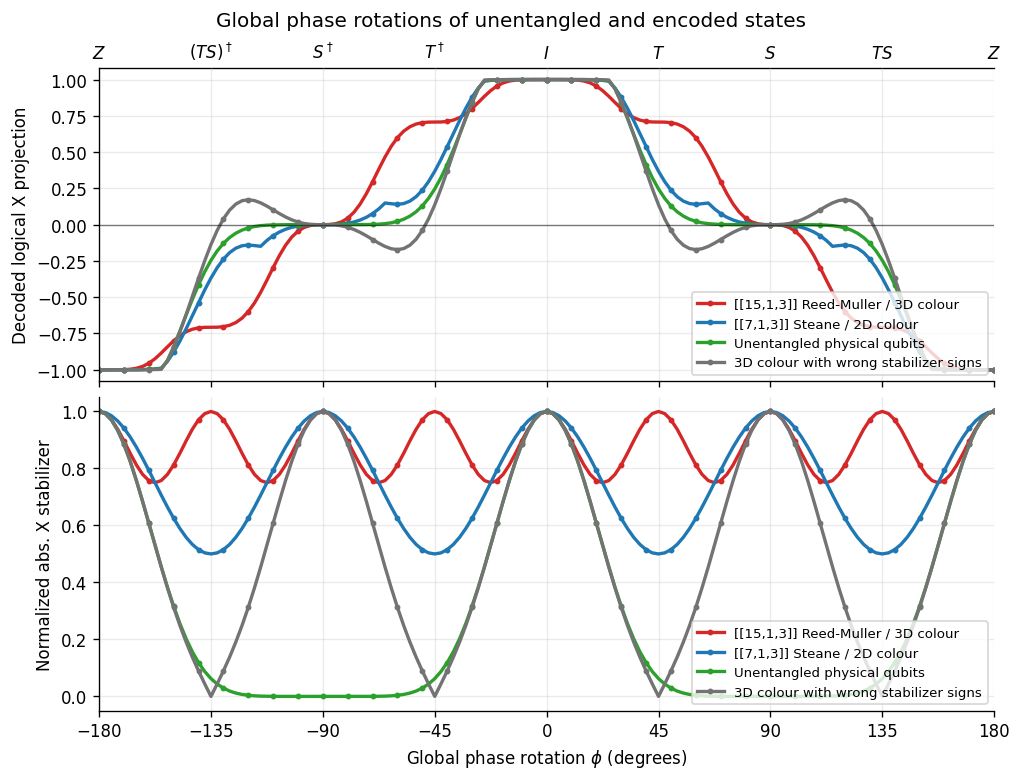

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(8.4, 6.4), sharex=True, constrained_layout=True)

plot_order = [
    "[[15,1,3]] Reed-Muller / 3D colour",
    "[[7,1,3]] Steane / 2D colour",
    "Unentangled physical qubits",
    "3D colour with wrong stabilizer signs",
]
plot_styles = {
    "[[15,1,3]] Reed-Muller / 3D colour": {"color": "tab:red"},
    "[[7,1,3]] Steane / 2D colour": {"color": "tab:blue"},
    "Unentangled physical qubits": {"color": "tab:green"},
    "3D colour with wrong stabilizer signs": {"color": "0.45"},
}

for label in plot_order:
    curve = curves[label]
    axes[0].plot(
        curve.angles,
        normalize_signed(curve.decoded_logical_x),
        linewidth=2,
        marker="o",
        markersize=2.5,
        markevery=4,
        label=label,
        **plot_styles[label],
    )
    axes[1].plot(
        curve.angles,
        normalize_positive(curve.stabilizer_abs),
        linewidth=2,
        marker="o",
        markersize=2.5,
        markevery=4,
        label=label,
        **plot_styles[label],
    )

axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_ylabel("Decoded logical X projection")
axes[1].set_ylabel("Normalized abs. X stabilizer")
axes[1].set_xlabel(r"Global phase rotation $\phi$ (degrees)")

for axis in axes:
    axis.set_xlim(-180, 180)
    axis.set_xticks(SPECIAL_ANGLES)
    axis.legend(loc="lower right", fontsize=8)
axes[0].set_ylim(-1.08, 1.08)
axes[1].set_ylim(-0.05, 1.05)

phase_axis = axes[0].secondary_xaxis("top")
phase_axis.set_xticks(SPECIAL_ANGLES)
phase_axis.set_xticklabels(
    [
        r"$Z$",
        r"$(TS)^\dagger$",
        r"$S^\dagger$",
        r"$T^\dagger$",
        r"$I$",
        r"$T$",
        r"$S$",
        r"$TS$",
        r"$Z$",
    ]
)
phase_axis.tick_params(length=0)

fig.suptitle("Global phase rotations of unentangled and encoded states")
if SAVE_FIGURES:
    fig.savefig("global_rotations_fig4a_style.png", dpi=240, bbox_inches="tight")
plt.show()

## 11. Decoded and raw logical-response diagnostics

The main figure uses the decoded logical response because that is the quantity that produces the plateau structure after syndrome information is interpreted. The next plot compares it with the raw Pauli expectation $\langle X_L\rangle$.

The difference is largest for the 3D Reed-Muller curve. The raw expectation has the correct values at the exact T, S, and Z angles, but it varies too smoothly between them. The decoded curve is flatter around the protected angles because nearby low-weight syndrome sectors are corrected before the logical X outcome is averaged.

The signed stabilizer panel is also shown without absolute values. It separates a stabilizer revival with the correct sign from a stabilizer revival in a wrong sign sector.


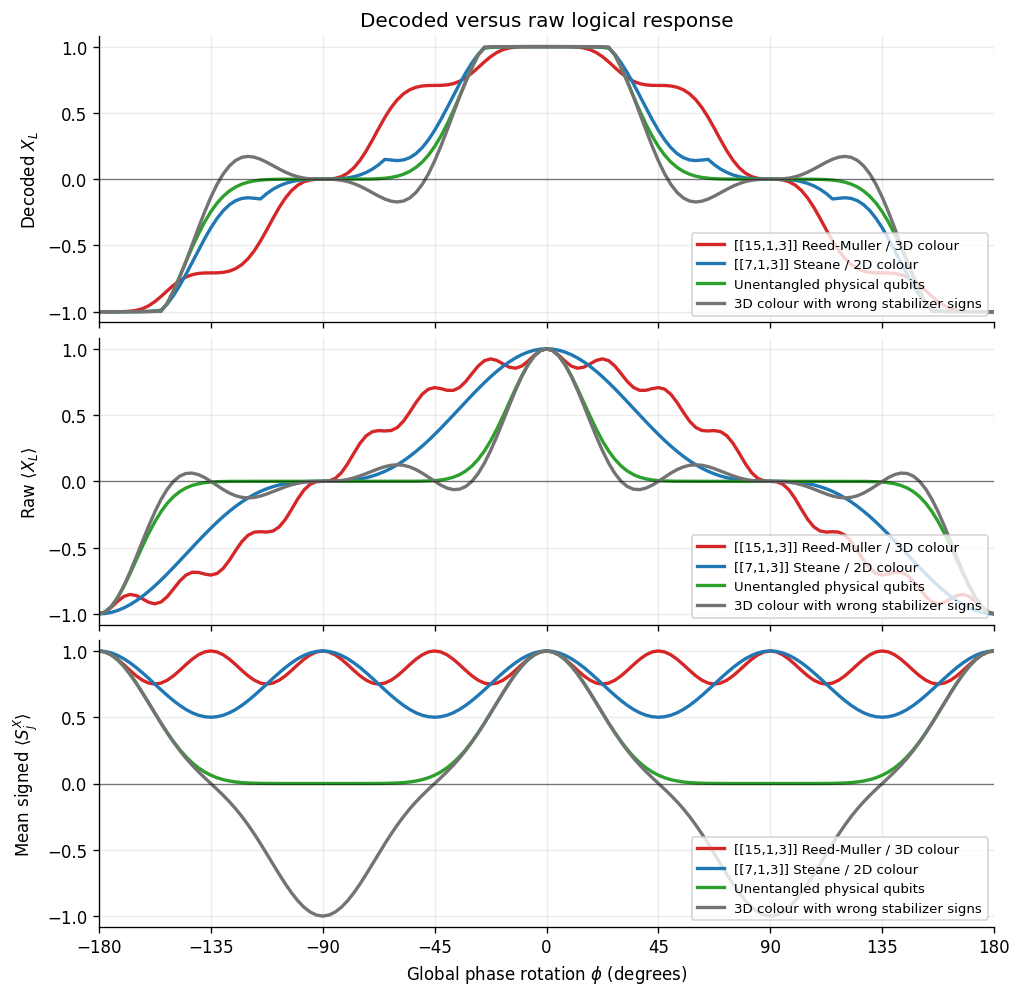

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(8.4, 8.2), sharex=True, constrained_layout=True)

for label in plot_order:
    curve = curves[label]
    axes[0].plot(
        curve.angles,
        curve.decoded_logical_x,
        linewidth=2,
        label=label,
        **plot_styles[label],
    )
    axes[1].plot(
        curve.angles,
        curve.logical_x,
        linewidth=2,
        label=label,
        **plot_styles[label],
    )
    axes[2].plot(
        curve.angles,
        curve.stabilizer_signed,
        linewidth=2,
        label=label,
        **plot_styles[label],
    )

axes[0].set_title("Decoded versus raw logical response")
axes[0].set_ylabel("Decoded $X_L$")
axes[1].set_ylabel(r"Raw $\langle X_L\rangle$")
axes[2].set_ylabel(r"Mean signed $\langle S_j^X\rangle$")
axes[2].set_xlabel(r"Global phase rotation $\phi$ (degrees)")
for axis in axes:
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    axis.set_xlim(-180, 180)
    axis.set_xticks(SPECIAL_ANGLES)
    axis.legend(loc="lower right", fontsize=8)
    axis.set_ylim(-1.08, 1.08)
if SAVE_FIGURES:
    fig.savefig(
        "global_rotations_decoded_raw_diagnostic.png", dpi=240, bbox_inches="tight"
    )
plt.show()

## 12. Positive X-syndrome probability

The stabilizer absolute value says whether each stabilizer is definite. The projector probability says whether all X checks are specifically in the positive sector. The difference is important for non-Clifford transversal gates: a wrong stabilizer sign can be a perfectly sharp stabilizer, but it is not the stabilizer sector that implements the intended logical T gate.


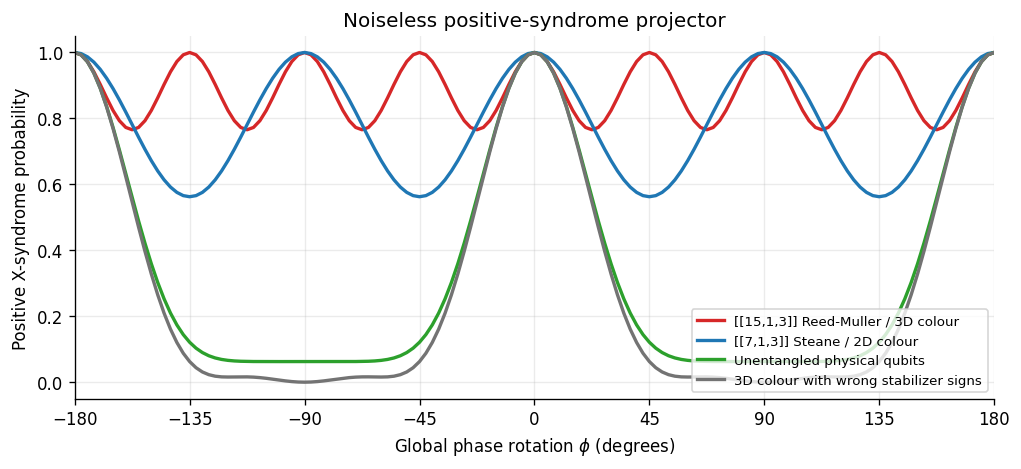

In [28]:
fig, axis = plt.subplots(figsize=(8.4, 3.8), constrained_layout=True)
for label in plot_order:
    curve = curves[label]
    axis.plot(
        curve.angles,
        curve.x_projector_probability,
        linewidth=2,
        label=label,
        **plot_styles[label],
    )
axis.set_xlim(-180, 180)
axis.set_ylim(-0.05, 1.05)
axis.set_xticks(SPECIAL_ANGLES)
axis.set_xlabel("Global phase rotation $\\phi$ (degrees)")
axis.set_ylabel("Positive X-syndrome probability")
axis.set_title("Noiseless positive-syndrome projector")
axis.legend(loc="lower right", fontsize=8)
if SAVE_FIGURES:
    fig.savefig(
        "global_rotations_positive_syndrome_probability.png",
        dpi=240,
        bbox_inches="tight",
    )
plt.show()

## 13. Logical equatorial Bloch-plane diagnostic

A global phase rotation around $Z_L$ moves an ideal logical $|+_L\rangle$ state in the logical X-Y plane. The plot below shows the logical equatorial response

$
(\langle X_L\rangle,\langle Y_L\rangle)
$

at multiples of 45 degrees.

This diagnostic makes the T-gate interpretation visible. The 3D Reed-Muller curve reaches the 45-degree equatorial directions while maintaining stabilizer revivals. The Steane code reaches the Clifford directions. The unentangled baseline has small logical-equatorial projections away from the trivial physical revivals because the observable is a 15-body product.


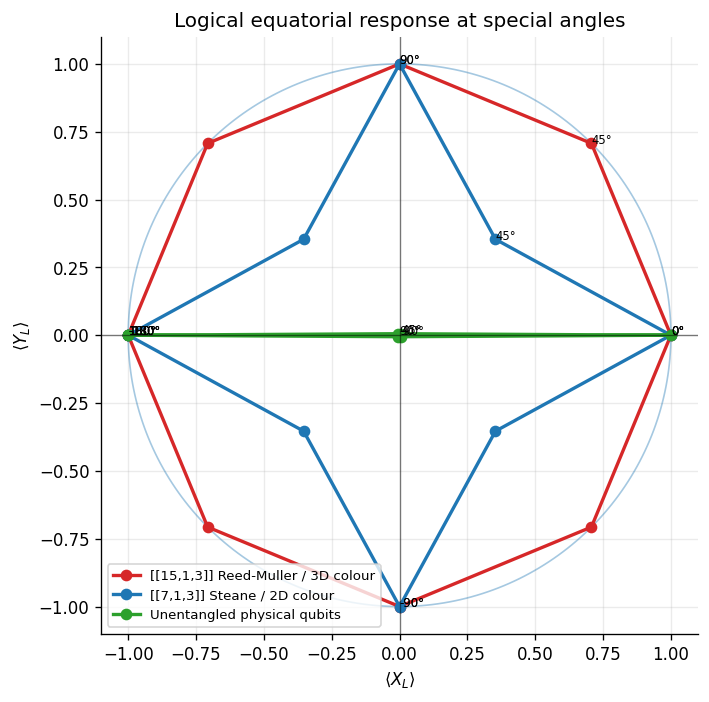

In [29]:
fig, axis = plt.subplots(figsize=(5.8, 5.8), constrained_layout=True)
unit = np.linspace(0, 2 * np.pi, 300)
axis.plot(np.cos(unit), np.sin(unit), linewidth=1, alpha=0.4)

for label in plot_order[:3]:
    system = next(system for system in systems if system.label == label)
    xs = []
    ys = []
    for angle in SPECIAL_ANGLES:
        state = rotate_state_from_base(system.base_state, system.n, float(angle))
        xs.append(observable_expectation(state, system.logical_x))
        ys.append(observable_expectation(state, system.logical_y))
    axis.plot(xs, ys, marker="o", linewidth=2, label=label, **plot_styles[label])
    for angle, x_value, y_value in zip(SPECIAL_ANGLES, xs, ys, strict=True):
        if angle in [-180, -90, 0, 45, 90, 180]:
            axis.text(x_value, y_value, f"{int(angle)}°", fontsize=7)

axis.axhline(0, color="black", linewidth=0.8, alpha=0.5)
axis.axvline(0, color="black", linewidth=0.8, alpha=0.5)
axis.set_aspect("equal", adjustable="box")
axis.set_xlim(-1.1, 1.1)
axis.set_ylim(-1.1, 1.1)
axis.set_xlabel("$\\langle X_L\\rangle$")
axis.set_ylabel("$\\langle Y_L\\rangle$")
axis.set_title("Logical equatorial response at special angles")
axis.legend(loc="lower left", fontsize=8)
if SAVE_FIGURES:
    fig.savefig(
        "global_rotations_logical_bloch_plane.png", dpi=240, bbox_inches="tight"
    )
plt.show()

## 14. Special-angle table and heat maps

The following table and heat maps summarize the expected plateaus.

- The decoded unentangled baseline has large response near the trivial physical revivals but lacks 3D stabilizer revivals.
- The Steane code has stabilizer revivals at multiples of 90 degrees.
- The all-positive Reed-Muller code has stabilizer revivals at multiples of 45 degrees and decoded T-angle logical-X value $1/\sqrt2$.
- The wrong-sign 3D control removes the T-angle stabilizer plateau.


| system | angle | decoded $X_L$ | raw $\langle X_L\rangle$ | abs. X stabilizer | positive X syndrome |
|---|---:|---:|---:|---:|---:|
| [[15,1,3]] Reed-Muller / 3D colour | -180° | -1.000 | -1.000 | 1.000 | 1.000 |
| [[15,1,3]] Reed-Muller / 3D colour | -135° | -0.707 | -0.707 | 1.000 | 1.000 |
| [[15,1,3]] Reed-Muller / 3D colour | -90° | -0.000 | -0.000 | 1.000 | 1.000 |
| [[15,1,3]] Reed-Muller / 3D colour | -45° | +0.707 | +0.707 | 1.000 | 1.000 |
| [[15,1,3]] Reed-Muller / 3D colour | +0° | +1.000 | +1.000 | 1.000 | 1.000 |
| [[15,1,3]] Reed-Muller / 3D colour | +45° | +0.707 | +0.707 | 1.000 | 1.000 |
| [[15,1,3]] Reed-Muller / 3D colour | +90° | -0.000 | -0.000 | 1.000 | 1.000 |
| [[15,1,3]] Reed-Muller / 3D colour | +135° | -0.707 | -0.707 | 1.000 | 1.000 |
| [[15,1,3]] Reed-Muller / 3D colour | +180° | -1.000 | -1.000 | 1.000 | 1.000 |
| [[7,1,3]] Steane / 2D colour | -180° | -1.000 | -1.000 | 1.000 | 1.000 |
| [[7,1,3]] Steane / 2D colour | -135° | -0.368 | -0.354 | 0.500 | 0.563 |
| [[7,1,3]] Steane / 2D colour | -90° | +0.000 | +0.000 | 1.000 | 1.000 |
| [[7,1,3]] Steane / 2D colour | -45° | +0.368 | +0.354 | 0.500 | 0.563 |
| [[7,1,3]] Steane / 2D colour | +0° | +1.000 | +1.000 | 1.000 | 1.000 |
| [[7,1,3]] Steane / 2D colour | +45° | +0.368 | +0.354 | 0.500 | 0.563 |
| [[7,1,3]] Steane / 2D colour | +90° | -0.000 | -0.000 | 1.000 | 1.000 |
| [[7,1,3]] Steane / 2D colour | +135° | -0.368 | -0.354 | 0.500 | 0.563 |
| [[7,1,3]] Steane / 2D colour | +180° | -1.000 | -1.000 | 1.000 | 1.000 |
| Unentangled physical qubits | -180° | -1.000 | -1.000 | 1.000 | 1.000 |
| Unentangled physical qubits | -135° | -0.246 | -0.006 | 0.062 | 0.121 |
| Unentangled physical qubits | -90° | +0.000 | +0.000 | 0.000 | 0.062 |
| Unentangled physical qubits | -45° | +0.246 | +0.006 | 0.062 | 0.121 |
| Unentangled physical qubits | +0° | +1.000 | +1.000 | 1.000 | 1.000 |
| Unentangled physical qubits | +45° | +0.246 | +0.006 | 0.062 | 0.121 |
| Unentangled physical qubits | +90° | +0.000 | +0.000 | 0.000 | 0.062 |
| Unentangled physical qubits | +135° | -0.246 | -0.006 | 0.062 | 0.121 |
| Unentangled physical qubits | +180° | -1.000 | -1.000 | 1.000 | 1.000 |
| 3D colour with wrong stabilizer signs | -180° | -1.000 | -1.000 | 1.000 | 1.000 |
| 3D colour with wrong stabilizer signs | -135° | -0.137 | -0.000 | 0.000 | 0.062 |
| 3D colour with wrong stabilizer signs | -90° | -0.000 | +0.000 | 1.000 | 0.000 |
| 3D colour with wrong stabilizer signs | -45° | +0.137 | -0.000 | 0.000 | 0.063 |
| 3D colour with wrong stabilizer signs | +0° | +1.000 | +1.000 | 1.000 | 1.000 |
| 3D colour with wrong stabilizer signs | +45° | +0.137 | +0.000 | 0.000 | 0.063 |
| 3D colour with wrong stabilizer signs | +90° | -0.000 | +0.000 | 1.000 | 0.000 |
| 3D colour with wrong stabilizer signs | +135° | -0.137 | -0.000 | 0.000 | 0.062 |
| 3D colour with wrong stabilizer signs | +180° | -1.000 | -1.000 | 1.000 | 1.000 |

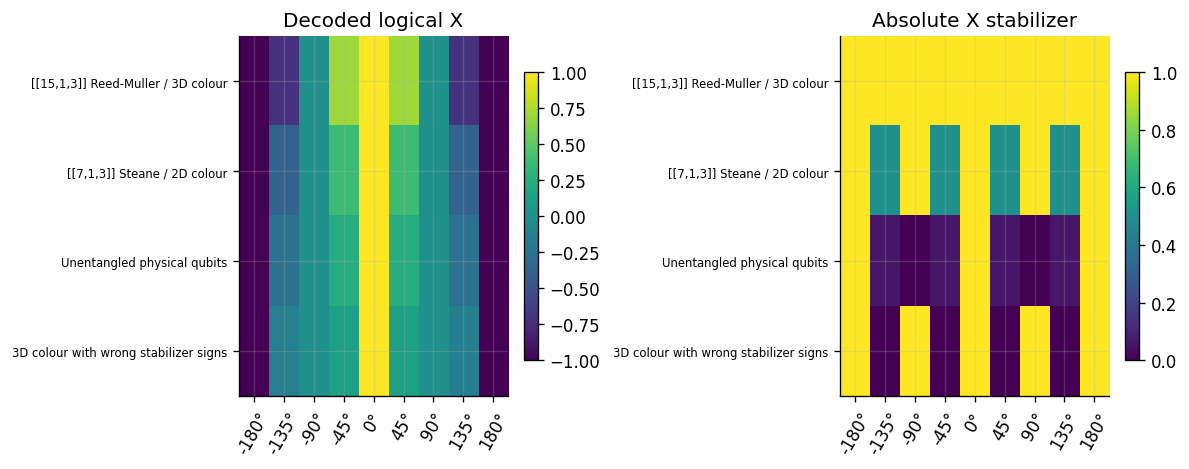

In [30]:
def curve_value_at(curve: CurveData, values: np.ndarray, angle: float) -> float:
    index = int(np.argmin(np.abs(curve.angles - angle)))
    return float(values[index])


summary_lines = [
    "| system | angle | decoded $X_L$ | raw $\\langle X_L\\rangle$ | abs. X stabilizer | positive X syndrome |",
    "|---|---:|---:|---:|---:|---:|",
]
for label in plot_order:
    curve = curves[label]
    for angle in SPECIAL_ANGLES:
        summary_lines.append(
            f"| {label} | {angle:+.0f}° | "
            f"{curve_value_at(curve, curve.decoded_logical_x, angle):+.3f} | "
            f"{curve_value_at(curve, curve.logical_x, angle):+.3f} | "
            f"{curve_value_at(curve, curve.stabilizer_abs, angle):.3f} | "
            f"{curve_value_at(curve, curve.x_projector_probability, angle):.3f} |"
        )
display(Markdown("\n".join(summary_lines)))

logical_heat = np.array(
    [
        [
            curve_value_at(curves[label], curves[label].decoded_logical_x, angle)
            for angle in SPECIAL_ANGLES
        ]
        for label in plot_order
    ]
)
stabilizer_heat = np.array(
    [
        [
            curve_value_at(curves[label], curves[label].stabilizer_abs, angle)
            for angle in SPECIAL_ANGLES
        ]
        for label in plot_order
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.8), constrained_layout=True)
left = axes[0].imshow(logical_heat, aspect="auto", vmin=-1, vmax=1)
right = axes[1].imshow(stabilizer_heat, aspect="auto", vmin=0, vmax=1)
axes[0].set_title("Decoded logical X")
axes[1].set_title("Absolute X stabilizer")
for axis in axes:
    axis.set_yticks(range(len(plot_order)))
    axis.set_yticklabels(plot_order, fontsize=7)
    axis.set_xticks(range(len(SPECIAL_ANGLES)))
    axis.set_xticklabels([f"{angle:.0f}°" for angle in SPECIAL_ANGLES], rotation=60)
fig.colorbar(left, ax=axes[0], shrink=0.8)
fig.colorbar(right, ax=axes[1], shrink=0.8)
if SAVE_FIGURES:
    fig.savefig(
        "global_rotations_special_angle_heatmaps.png", dpi=240, bbox_inches="tight"
    )
plt.show()

## 15. Optional sampling demonstration

The default notebook uses exact state vectors because the figure is meant to show a deterministic ideal phenomenon. Tsim can also sample measurement circuits. The optional cell below samples the Steane code in the X basis and overlays finite-shot estimates on the exact logical-X curve.

Set `RUN_SAMPLING_DEMO = True` in the flags cell to run it. The random seed is fixed.


In [31]:
if RUN_SAMPLING_DEMO:
    rng_angles = np.linspace(-180, 180, 25)
    shots = 2000
    sampled_x = []
    sampled_err = []
    logical_support = np.array(
        [i for i, p in enumerate(steane_logical_x.pauli) if p == "X"]
    )
    for angle in rng_angles:
        sampling_circuit = append_global_rz(steane_base_circuit, float(angle))
        sampling_circuit.append("MX", list(range(steane_n)))
        sampler = sampling_circuit.compile_sampler(seed=RNG_SEED)
        samples = sampler.sample(shots, batch_size=shots)
        parity = np.mod(samples[:, logical_support].sum(axis=1), 2)
        values = 1 - 2 * parity
        sampled_x.append(float(np.mean(values)))
        sampled_err.append(float(np.std(values, ddof=1) / np.sqrt(shots)))

    exact_steane = curves["[[7,1,3]] Steane / 2D colour"]
    fig, axis = plt.subplots(figsize=(8.2, 3.8), constrained_layout=True)
    axis.plot(exact_steane.angles, exact_steane.logical_x, linewidth=2, label="exact")
    axis.errorbar(
        rng_angles,
        sampled_x,
        yerr=sampled_err,
        fmt="o",
        label=f"sampled, {shots} shots",
    )
    axis.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    axis.set_xlim(-180, 180)
    axis.set_ylim(-1.08, 1.08)
    axis.set_xticks(SPECIAL_ANGLES)
    axis.set_xlabel("Global phase rotation $\\phi$ (degrees)")
    axis.set_ylabel("Steane $\\langle X_L\\rangle$")
    axis.set_title("Optional Tsim sampling check")
    axis.legend()
    plt.show()
else:
    print("Sampling demo is disabled. Set RUN_SAMPLING_DEMO = True to run it.")

Sampling demo is disabled. Set RUN_SAMPLING_DEMO = True to run it.


## 16. Optional CuPy dense-vector path for GPU runtimes

This section is intentionally separate from the default calculation. It is useful only if you want to experiment with GPU array operations in Colab. It does not change Tsim's compilation path, and it is not expected to help much at 15 qubits because the arrays have only 32768 amplitudes.

Set `USE_CUPY_FOR_DENSE_EXPECTATIONS = True` in the flags cell and run this section on a GPU runtime. If CuPy is missing, the cell installs `cupy-cuda12x`.


In [32]:
if USE_CUPY_FOR_DENSE_EXPECTATIONS:
    try:
        import cupy as cp
    except ModuleNotFoundError:
        if not IN_COLAB:
            raise
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "cupy-cuda12x"]
        )
        import cupy as cp

    @cache
    def cupy_pauli_action(pauli: str):
        partner, phase = pauli_action(pauli)
        return cp.asarray(partner), cp.asarray(phase)

    def cupy_rotate_state_from_base(
        base_state: np.ndarray, n: int, angle_degrees: float
    ):
        theta = np.deg2rad(angle_degrees)
        weights = cp.asarray(hamming_weights(n))
        phases = cp.exp(-0.5j * theta * (n - 2 * weights))
        return cp.asarray(base_state) * phases

    def cupy_pauli_expectation(state_gpu, pauli: str) -> float:
        partner, phase = cupy_pauli_action(pauli)
        value = cp.sum(cp.conjugate(state_gpu[partner]) * phase * state_gpu)
        return float(cp.asnumpy(cp.real(value)))

    start = time.perf_counter()
    gpu_values = []
    for angle in ANGLE_DEGREES:
        state_gpu = cupy_rotate_state_from_base(rm_base_state, rm_n, float(angle))
        gpu_values.append(cupy_pauli_expectation(state_gpu, rm_logical_x.pauli))
    cp.cuda.Stream.null.synchronize()
    elapsed = time.perf_counter() - start

    cpu_values = curves["[[15,1,3]] Reed-Muller / 3D colour"].logical_x
    max_difference = float(np.max(np.abs(np.asarray(gpu_values) - cpu_values)))
    print(f"CuPy Reed-Muller logical-X curve: {elapsed:.3f} s")
    print(f"maximum CPU/GPU difference: {max_difference:.3e}")
else:
    print(
        "CuPy path is disabled. Set USE_CUPY_FOR_DENSE_EXPECTATIONS = True to run it."
    )

CuPy path is disabled. Set USE_CUPY_FOR_DENSE_EXPECTATIONS = True to run it.


## 17. Reading the curves

### Unentangled physical qubits

The unentangled register has no code-space entanglement. A global rotation is just 15 independent one-qubit rotations. In the diagnostic plot, its raw logical-X proxy is $\cos^{15}\phi$, so it is strongly suppressed except near $0$ and $\pm180^\circ$. In the main plot the baseline is still passed through the same 15-qubit X-basis decoder and 46% correction-weight acceptance cut used for the 3D-style curves. This makes it a fair comparison to the paper's unentangled control: the baseline has the same number of qubits and the same classical analysis style, but no entangled code-space revivals.

### Steane / 2D colour code

The Steane code protects against small coherent rotations by moving low-weight $Z$ -error components into nontrivial syndrome sectors. At global 90-degree rotations, the code stabilizers revive because the operation is a transversal Clifford phase gate. The decoded logical X projection has the expected Clifford structure: it is near +1 around identity, near zero around $S$ and $S^\dagger$, and near -1 around logical $Z$. The stabilizer response does not revive at 45 degrees, so the 2D curve does not have a genuine T-angle plateau.

### Reed-Muller / 3D colour code

The Reed-Muller code has the Steane Clifford revivals and an additional 45-degree revival. At $45^\circ$, the stabilizers remain definite and the decoded logical X projection is $1/\sqrt2$, which is the expected X projection of a T-rotated $|+_L\rangle$. The minimum-weight X-basis decoder turns nearby low-weight syndrome sectors back into the same logical sector, producing visible plateaus around $T$, $T^\dagger$, $S$, and $S^\dagger$. This is the central Fig. 4a mechanism: the 3D code turns 15 physical T rotations into one encoded T rotation rather than 15 uncontrolled physical rotations.

### Wrong stabilizer signs

The wrong-sign 3D control shows that entanglement alone is not enough. The stabilizer sector must also be the correct one. The control is a sharp stabilizer state at zero angle, but the 45-degree T plateau is removed.


## 18. Limitations

This notebook is an ideal tutorial calculation. It does not reproduce experimental data.

The omitted experimental ingredients include atom loss, SPAM error, Rydberg-gate error, mid-circuit measurement, hardware lookup-table data, loss postselection, purity normalization, and the hardware hypercube encoding pulse sequence. The notebook does include an ideal minimum-weight lookup-table decoder and deterministic acceptance-fraction cut because those are needed to display the same plateau observable that Fig. 4a emphasizes.

The Reed-Muller preparation is a verified stabilizer-state preparation synthesized from the code checks. That is enough for the ideal global-rotation calculation because all plotted observables depend on the state, the stabilizers, the logical operators, and the global rotation. It is not a claim that this circuit matches the neutral-atom encoder.

The optional GPU section accelerates only dense-vector array operations.
